In [28]:
import pandas as pd 
import numpy as np 
df=pd.read_csv("Social_Network_Ads.csv")
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [29]:
df.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [30]:
x=df[['Age','EstimatedSalary']]
y=df['Purchased']

In [31]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [32]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

# ADA BOOST

In [33]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
dtc=DecisionTreeClassifier(max_depth=1)
classifier=AdaBoostClassifier(base_estimator=dtc,n_estimators=10,learning_rate=0.1,random_state=42)
classifier.fit(x_train,y_train)

AdaBoostClassifier(base_estimator=DecisionTreeClassifier(max_depth=1),
                   learning_rate=0.1, n_estimators=10, random_state=42)

Accuracy: 0.9125
Confusion Matrix:
 [[50  2]
 [ 5 23]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.96      0.93        52
           1       0.92      0.82      0.87        28

    accuracy                           0.91        80
   macro avg       0.91      0.89      0.90        80
weighted avg       0.91      0.91      0.91        80



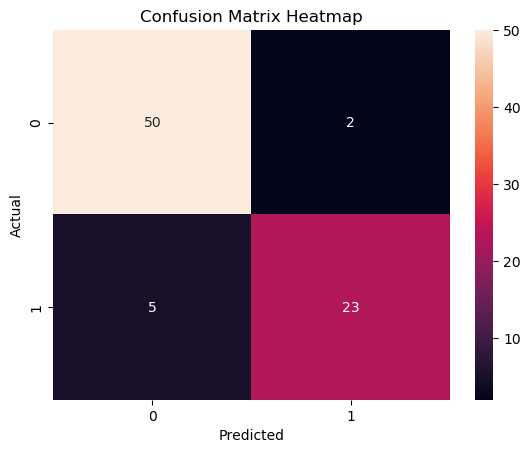

In [34]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
import seaborn as sns
import matplotlib.pyplot as plt
y_pred=classifier.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
confusion=confusion_matrix(y_test,y_pred)
report=classification_report(y_test,y_pred)
print("Accuracy:",accuracy)
print("Confusion Matrix:\n",confusion)
print("Classification Report:\n",report)
sns.heatmap(confusion,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()


Gradient Boosting Classifier Results:
Accuracy: 0.8625
Confusion Matrix:
 [[47  5]
 [ 6 22]]
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.90      0.90        52
           1       0.81      0.79      0.80        28

    accuracy                           0.86        80
   macro avg       0.85      0.84      0.85        80
weighted avg       0.86      0.86      0.86        80



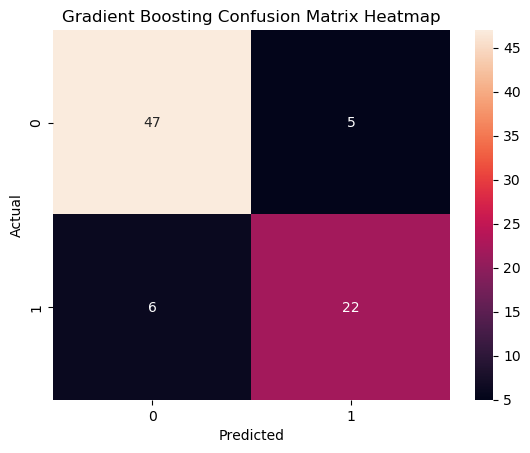

In [35]:
from sklearn.ensemble import GradientBoostingClassifier
gradient_boosting=GradientBoostingClassifier(n_estimators=100,learning_rate=0.1,max_depth=3,random_state=42)
gradient_boosting.fit(x_train,y_train)
y_pred_gb=gradient_boosting.predict(x_test) 
accuracy_gb=accuracy_score(y_test,y_pred_gb)
confusion_gb=confusion_matrix(y_test,y_pred_gb)
report_gb=classification_report(y_test,y_pred_gb)
print("Gradient Boosting Classifier Results:")
print("Accuracy:",accuracy_gb)
print("Confusion Matrix:\n",confusion_gb)
print("Classification Report:\n",report_gb)
sns.heatmap(confusion_gb,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Gradient Boosting Confusion Matrix Heatmap')
plt.show()

XGBoost Classifier Results:
Accuracy: 0.9125
Confusion Matrix:
 [[48  4]
 [ 3 25]]
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.92      0.93        52
           1       0.86      0.89      0.88        28

    accuracy                           0.91        80
   macro avg       0.90      0.91      0.90        80
weighted avg       0.91      0.91      0.91        80



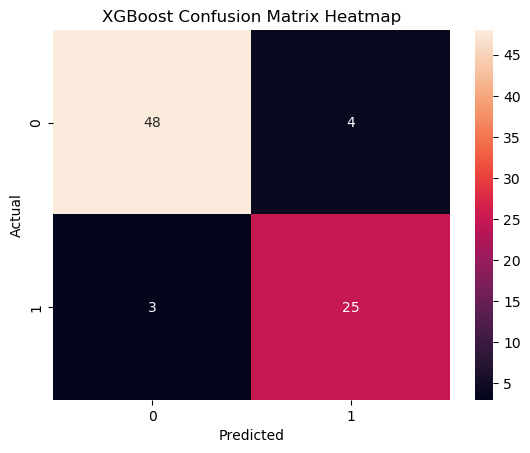

In [37]:
from xgboost import XGBClassifier
xgb_classifier=XGBClassifier(n_estimators=100,learning_rate=0.1,max_depth=3,random_state=42,subsample=0.8,colsample_bytree=0.8,use_label_encoder=False,eval_metric='logloss')
xgb_classifier.fit(x_train,y_train)
y_pred_xgb=xgb_classifier.predict(x_test)
accuracy_xgb=accuracy_score(y_test,y_pred_xgb)
confusion_xgb=confusion_matrix(y_test,y_pred_xgb)
report_xgb=classification_report(y_test,y_pred_xgb)
print("XGBoost Classifier Results:")
print("Accuracy:",accuracy_xgb)
print("Confusion Matrix:\n",confusion_xgb)
print("Classification Report:\n",report_xgb)
sns.heatmap(confusion_xgb,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost Confusion Matrix Heatmap')
plt.show()